# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Muhammad Dafa Alvian Ramadhani
- **Email:** dafaalvian17@gmail.com
- **ID Dicoding:** cdcc284d6y2233

## Menentukan Pertanyaan Bisnis

Berdasarkan dataset e-commerce yang digunakan, berikut merupakan pertanyaan pertanyaan yang akan dijawab melalui proses analisis data:

1. Produk apa yang memiliki penjualan tertinggi berdasarkan total quantity dalam periode dataset yang tersedia?
2. Bagaimana tren jumlah transkasi dari waktu ke waktu berdasarkan tanggal pembelian?
3. Siapa saja pelanggan dengan jumlah transaksi terbanyak selama periode dataset dan bagaimana distribusi aktivitas pembelian mereka?
4. Kategori produk apa yang paling banyak terjual berdasarkan jumlah item yang dibeli oleh pelanggan selama periode dataset?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import Library

Pda tahapan ini, dilakukan import library yang akan digunakan pada proses analisis data. Librarynya sebagai berikut:
- **Numpy**: Digunakan untuk komputasi numerik
- **Pandas**: Digunakan untuk manipulasi data dan analisis data
- **Matplotlib**: Digunakan untuk visualisasi data
- **Seaborn**: Membuat visualisasi data lebih menarik

## Data Wrangling

### Gathering Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
orders_df = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/orders_dataset.csv')
order_items_df = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/order_items_dataset.csv')
products_df = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/products_dataset.csv')
customers_df = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/customers_dataset.csv')

In [4]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Data Wrangling - Gathering Data**

Pada tahap ini dilakukan proses pengumpulan data dengan memuat beberapa dataset yang akan digunakan dalam analisis. Dataset yang digunakan antara lain:

- orders_dataset.csv
- order_items_dataset.csv
- products_dataset.csv
- customers_dataset.csv

Setiap dataset dimuat ke dalam DataFrame menggunakan library pandas, kemudian ditampilkan lima baris pertama untuk memahami struktur data.

**Insight:**
- Dataset terdiri dari beberapa tabel utama yaitu orders, order_items, products, dan customers.
- Setiap dataset memiliki fungsi yang berbeda, seperti orders untuk informasi transaksi, order_items untuk detail produk yang dibeli, products untuk informasi produk, dan customers untuk informasi pelanggan.
- Data yang dimuat sudah berhasil dibaca ke dalam DataFrame dan siap untuk dilakukan tahap analisis selanjutnya.

### Assessing Data

1. Cek info struktur dataset

In [8]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [9]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [10]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [11]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


2. Cek Missing Value

In [12]:
orders_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [13]:
order_items_df.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [14]:
products_df.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [15]:
customers_df.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


3. Cek Duplikat Data

In [16]:
orders_df.duplicated().sum()

np.int64(0)

In [17]:
order_items_df.duplicated().sum()

np.int64(0)

In [18]:
products_df.duplicated().sum()

np.int64(0)

In [19]:
customers_df.duplicated().sum()

np.int64(0)

4. Cek Invalid Data



In [20]:
orders_df['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [21]:
(order_items_df['price']< 0).sum()

np.int64(0)

In [22]:
(order_items_df['order_item_id']< 0).sum()

np.int64(0)

In [23]:
(order_items_df['freight_value']< 0).sum()

np.int64(0)

In [24]:
(products_df['product_name_lenght'] < 0).sum()

np.int64(0)

In [25]:
(products_df['product_description_lenght'] < 0).sum()

np.int64(0)

In [26]:
customers_df['customer_state'].value_counts()

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [27]:
customers_df['customer_city'].value_counts().head()

,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521


5. descriptive statistic


In [28]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
- Berdasarkan hasil pemeriksaan struktur data, ditemukan bahwa beberapa kolom yang berkaitan dengan waktu seperti `order_purchase_timestamp`, `order_approved_at`, dll masih bertipe data object, sehingga perlu dikonversi ke tipe datetime pada tahap cleaning data.

- Ditemukan missing value pada dataset `orders_df`, khususnya pada kolom:
  - `order_approved_at` sebanyak 160 data
  - `order_delivered_carrier_date` sebanyak 1783 data
  - `order_delivered_customer_date` sebanyak 2965 data

- Selain itu, dataset `products_df` memiliki missing value yang cukup signifikan pada beberapa kolom seperti `product_category_name`, `product_name_lenght`, `product_description_lenght`, dan atribut produk lainnya dengan total sekitar 610 data kosong. Beberapa kolom numerik seperti `product_weight_g`, `product_length_cm`, `product_height_cm`, dan `product_width_cm` juga memiliki missing value dalam jumlah kecil.

- Tidak ditemukan data duplikat pada seluruh dataset yang digunakan.

- Berdasarkan pemeriksaan nilai data, tidak ditemukan nilai yang tidak valid seperti nilai negatif pada kolom numerik maupun kategori yang tidak wajar pada kolom kategorikal.

- Berdasarkan hasil statistik deskriptif pada dataset `order_items_df`, sebagian besar transaksi hanya terdiri dari satu item. Selain itu, terdapat perbedaan yang cukup signifikan antara nilai median dan nilai maksimum pada kolom `price` dan `freight_value`, yang mengindikasikan adanya distribusi data yang skewed serta kemungkinan adanya outlier.

- Secara keseluruhan, dataset memiliki kualitas yang cukup baik, namun memerlukan proses pembersihan data terutama dalam penanganan missing value dan konversi tipe data sebelum dilakukan analisis lebih lanjut.

### Cleaning Data

1. konversi format

In [29]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

In [30]:
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

2. handle missing value

In [31]:
orders_df_clean = orders_df[orders_df['order_status'] == 'delivered']

order_df_clean = orders_df_clean.dropna(subset=['order_delivered_customer_date', 'order_delivered_carrier_date'])

In [32]:
orders_df_clean.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


In [33]:
orders_df_clean = orders_df_clean.dropna()

In [34]:
orders_df_clean.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


- Meskipun terdapat cukup banyak missing value pada beberapa kolom di dataset orders seperti `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`, data tidak dihapus atau diisi secara langsung karena nilai kosong tersebut hanya terjadi pada kolom tertentu dan tidak mempengaruhi keseluruhan informasi transaksi.

- Nilai kosong tersebut juga berkaitan dengan status pesanan, seperti pesanan yang belum selesai atau dibatalkan, sehingga masih merepresentasikan kondisi nyata dalam data.

- Oleh karena itu, penanganan missing value dilakukan secara kontekstual dengan memfilter data yang relevan, yaitu pesanan dengan status delivered dan memiliki informasi pengiriman yang lengkap.

In [35]:
products_df = products_df.dropna(subset=['product_category_name'])

In [36]:
products_df.isnull().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,1
product_length_cm,1
product_height_cm,1
product_width_cm,1


- Setelah dilakukan penghapusan missing value pada kolom `product_category_name`, masih terdapat sejumlah kecil missing value pada beberapa kolom numerik seperti dimensi dan berat produk.

- Namun, karena jumlahnya sangat kecil dan tidak berpengaruh signifikan terhadap analisis yang dilakukan, data tersebut tetap dipertahankan.

**Insight:**
- Data yang berkaitan dengan waktu telah dikonversi ke format datetime sehingga lebih mudah digunakan untuk analisis berbasis waktu.

- Missing value pada dataset orders tidak ditangani secara langsung secara keseluruhan, melainkan difokuskan pada data yang relevan untuk analisis, yaitu pesanan dengan status delivered.

- Setelah dilakukan pembersihan, masih ditemukan sedikit data yang tidak konsisten dan kemudian dihapus karena jumlahnya sangat kecil.

- Pada dataset products, data tanpa kategori produk dihapus karena tidak cukup informatif untuk analisis.

- Meskipun terdapat indikasi outlier pada beberapa kolom numerik seperti `price` dan `freight_value`, data tersebut tidak dihapus karena nilai ekstrem masih memungkinkan terjadi dalam konteks transaksi e-commerce, seperti produk dengan harga tinggi atau biaya pengiriman yang besar.

- Penghapusan outlier tanpa analisis mendalam berpotensi menghilangkan informasi penting yang justru merepresentasikan kondisi nyata dari data.
Oleh karena itu, data tetap dipertahankan agar hasil analisis tetap mencerminkan kondisi sebenarnya.

- Secara keseluruhan, proses cleaning dilakukan secara selektif agar data tetap realistis namun cukup bersih untuk dianalisis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [37]:
# Menggabungkan dataset

# Menggabungkan orders_items

orders_items_df = pd.merge(
    orders_df,
    order_items_df,
    on = 'order_id',
    how = 'inner'
)

# Menggabungkan dengan products
all_df = pd.merge(
    orders_items_df,
    products_df,
    on = 'product_id',
    how = 'inner'
)

# Menggabungkan dengan customers
all_df = pd.merge(
    all_df,
    customers_df,
    on = 'customer_id',
    how = 'inner'
)

all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [38]:
all_df.shape

(111047, 26)

In [39]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111047 entries, 0 to 111046
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       111047 non-null  object        
 1   customer_id                    111047 non-null  object        
 2   order_status                   111047 non-null  object        
 3   order_purchase_timestamp       111047 non-null  datetime64[ns]
 4   order_approved_at              111033 non-null  datetime64[ns]
 5   order_delivered_carrier_date   109890 non-null  datetime64[ns]
 6   order_delivered_customer_date  108659 non-null  datetime64[ns]
 7   order_estimated_delivery_date  111047 non-null  datetime64[ns]
 8   order_item_id                  111047 non-null  int64         
 9   product_id                     111047 non-null  object        
 10  seller_id                      111047 non-null  object        
 11  

In [40]:
all_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix
count,111047,111033,109890,108659,111047,111047.000000,111047,111047.000000,111047.000000,111047.000000,111047.000000,111047.000000,111046.000000,111046.000000,111046.000000,111046.000000,111047.000000
mean,2018-01-01 18:36:26.769205504,2018-01-02 06:10:06.729954304,2018-01-05 20:23:33.779215616,2018-01-15 07:23:45.339300096,2018-01-25 14:45:25.181229568,1.198213,2018-01-08 10:05:09.240672768,120.778665,20.025212,48.775978,787.867029,2.209713,2099.979657,30.211003,16.626362,23.041956,35110.181887
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000,2016-09-19 00:15:34,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1003.000000
25%,2017-09-14 12:10:23,2017-09-14 20:45:12,2017-09-19 15:03:28.750000128,2017-09-27 18:05:01,2017-10-05 00:00:00,1.000000,2017-09-21 04:47:36.500000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,11320.000000
50%,2018-01-21 12:16:51,2018-01-22 14:00:22,2018-01-25 14:11:28,2018-02-05 13:29:43,2018-02-16 00:00:00,1.000000,2018-01-28 23:18:29,74.990000,16.300000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,24340.000000
75%,2018-05-05 19:24:27,2018-05-06 11:50:29,2018-05-08 15:38:30,2018-05-16 15:52:28,2018-05-28 00:00:00,1.000000,2018-05-11 00:23:03.500000,134.900000,21.180000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,59017.500000
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99980.000000
std,NaN,NaN,NaN,NaN,NaN,0.706872,NaN,183.419692,15.840571,10.025581,652.135608,1.721438,3754.785226,16.189352,13.467460,11.716659,29854.529064


In [41]:
# Eksplorasi jumlah transaksi berdasarkan produk
all_df.groupby('product_id')['order_item_id'].count().sort_values(ascending=False).head()

,order_item_id
product_id,
aca2eb7d00ea1a7b8ebd4e68314663af,527
99a4788cb24856965c36a24e339b6058,488
422879e10f46682990de24d770e7f83d,484
389d119b48cf3043d311335e499d9c6b,392
368c6c730842d78016ad823897a372db,388


In [42]:
# Eksplorasi berdasarkan kategori produk
all_df.groupby('product_category_name')['order_item_id'].count().sort_values(ascending=False).head()

,order_item_id
product_category_name,
cama_mesa_banho,11115
beleza_saude,9670
esporte_lazer,8641
moveis_decoracao,8334
informatica_acessorios,7827


In [43]:
# Eksplorasi aktivitas pelanggan
all_df.groupby('customer_id')['order_id'].nunique().sort_values(ascending=False).head()

,order_id
customer_id,
ffffa3172527f765de70084a7e53aae8,1
00012a2ce6f8dcda20d059ce98491703,1
000161a058600d5901f007fab4c27140,1
0001fd6190edaaf884bcaf3d49edf079,1
0002414f95344307404f0ace7a26f1d5,1


In [44]:
# Eksplorasi distribusi waktu transaksi
all_df['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()

,count
order_purchase_timestamp,
2016-09,6
2016-10,361
2016-12,1
2017-01,942
2017-02,1893
2017-03,2937
2017-04,2613
2017-05,4040
2017-06,3520


**Insight:**
- Setelah dilakukan penggabungan beberapa dataset, diperoleh data yang lebih lengkap yang mencakup informasi transaksi, produk, dan pelanggan.

- Dari eksplorasi awal, terlihat bahwa jumlah transaksi antar produk dan kategori tidak merata, yang menunjukkan adanya perbedaan tingkat penjualan.

- Aktivitas pelanggan juga bervariasi, di mana terdapat pelanggan yang melakukan transaksi lebih sering dibandingkan pelanggan lainnya.

- Berdasarkan waktu transaksi, terlihat adanya pola tertentu yang dapat digunakan untuk melihat tren aktivitas pembelian.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk apa yang memiliki penjualan tertinggi berdasarkan total quantity dalam periode dataset yang tersedia?

In [45]:
product_sales = all_df.groupby('product_id')['order_item_id'].count().sort_values(ascending = False)

top_products = product_sales.head(10)
top_products

,order_item_id
product_id,
aca2eb7d00ea1a7b8ebd4e68314663af,527
99a4788cb24856965c36a24e339b6058,488
422879e10f46682990de24d770e7f83d,484
389d119b48cf3043d311335e499d9c6b,392
368c6c730842d78016ad823897a372db,388
53759a2ecddad2bb87a079a1f1519f73,373
d1c427060a0f73f6b889a5c7c61f2ac4,343
53b36df67ebb7c41585e8d54d6772e08,323
154e7e31ebfa092203795c972e5804a6,281


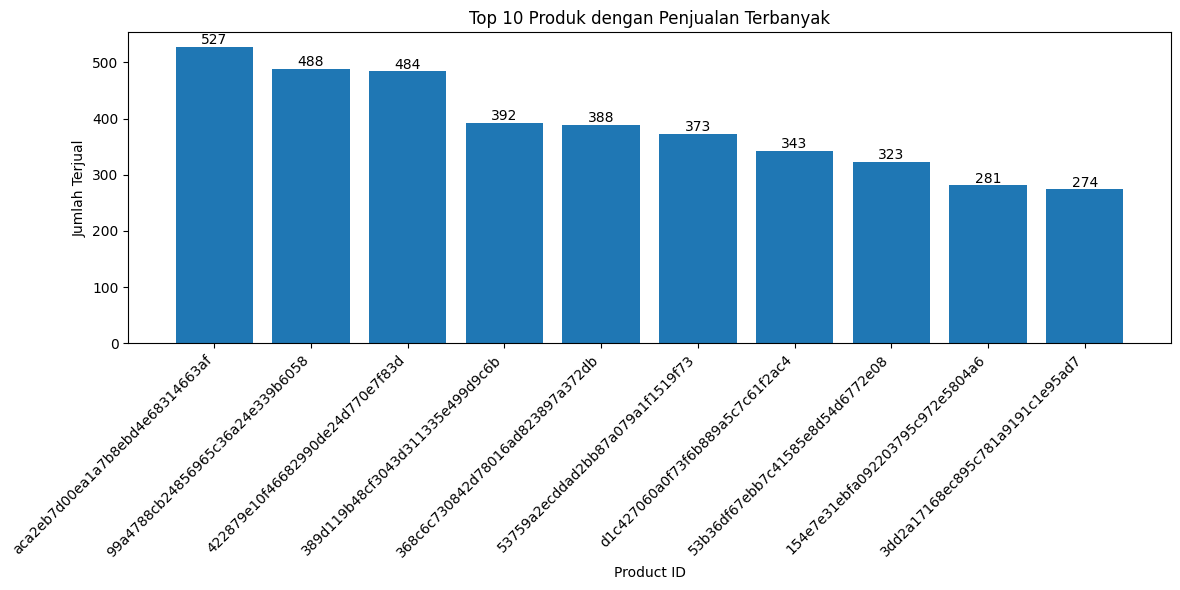

In [46]:
plt.figure(figsize=(12,6))

bars = plt.bar(top_products.index, top_products.values)

plt.title('Top 10 Produk dengan Penjualan Terbanyak')
plt.xlabel('Product ID')
plt.ylabel('Jumlah Terjual')

plt.xticks(rotation=45, ha='right')

for i, v in enumerate(top_products.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan hasil visualisasi, terlihat bahwa terdapat beberapa produk (berdasarkan product_id) yang memiliki jumlah penjualan lebih tinggi dibandingkan produk lainnya.

- Produk dengan jumlah penjualan tertinggi mencapai lebih dari 500 transaksi, sedangkan produk lainnya berada di bawahnya, menunjukkan adanya perbedaan tingkat permintaan antar produk.

- Hal ini menunjukkan bahwa tidak semua produk memiliki performa penjualan yang sama, di mana sebagian produk lebih dominan dalam transaksi.

- Produk dengan penjualan tertinggi dapat dianggap sebagai produk yang paling diminati oleh pelanggan selama periode dataset.

### Pertanyaan 2: Bagaimana tren jumlah transkasi dari waktu ke waktu berdasarkan tanggal pembelian?

In [47]:
monthly_orders = all_df.groupby(
    all_df['order_purchase_timestamp'].dt.to_period('M')
)['order_id'].nunique()

monthly_orders.index = monthly_orders.index.to_timestamp()
monthly_orders.head()

,order_id
order_purchase_timestamp,
2016-09-01,3
2016-10-01,306
2016-12-01,1
2017-01-01,778
2017-02-01,1681


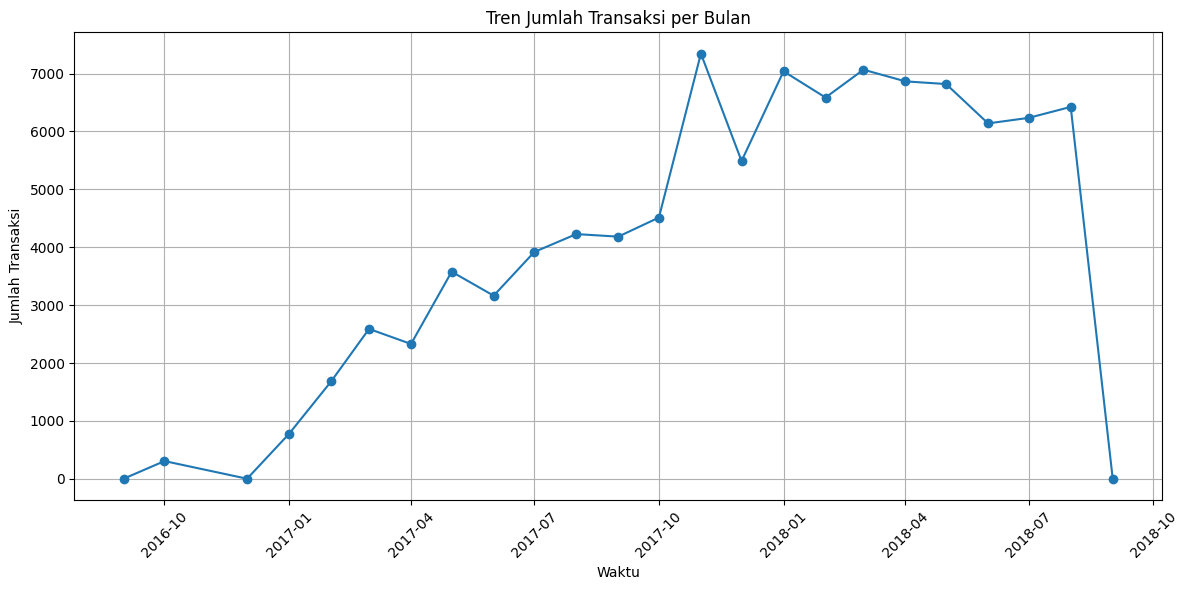

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker='o'
)

plt.title('Tren Jumlah Transaksi per Bulan')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Transaksi')

plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan visualisasi, jumlah transaksi menunjukkan tren peningkatan dari awal periode hingga mencapai puncaknya di sekitar akhir tahun 2017 hingga awal 2018.

- Setelah mencapai puncak, jumlah transaksi cenderung stabil dengan fluktuasi kecil di beberapa bulan berikutnya.

- Terdapat penurunan yang sangat signifikan di akhir periode, yang kemungkinan disebabkan oleh data yang belum lengkap pada bulan tersebut.

- Secara keseluruhan, tren ini menunjukkan adanya pertumbuhan aktivitas transaksi dari waktu ke waktu sebelum akhirnya stabil.

### Pertanyaan 3: Siapa saja pelanggan dengan jumlah transaksi terbanyak selama periode dataset dan bagaimana distribusi aktivitas pembelian mereka?

In [49]:
customer_transactions = all_df.groupby('customer_unique_id')['order_id'].nunique().sort_values(ascending=False)

top_customers = customer_transactions.head(10)
top_customers

,order_id
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,15
3e43e6105506432c953e165fb2acf44c,9
ca77025e7201e3b30c44b472ff346268,7
6469f99c1f9dfae7733b25662e7f1782,7
1b6c7548a2a1f9037c1fd3ddfed95f33,7
12f5d6e1cbf93dafd9dcc19095df0b3d,6
47c1a3033b8b77b3ab6e109eb4d5fdf3,6
dc813062e0fc23409cd255f7f53c7074,6
35ecdf6858edc6427223b64804cf028e,5


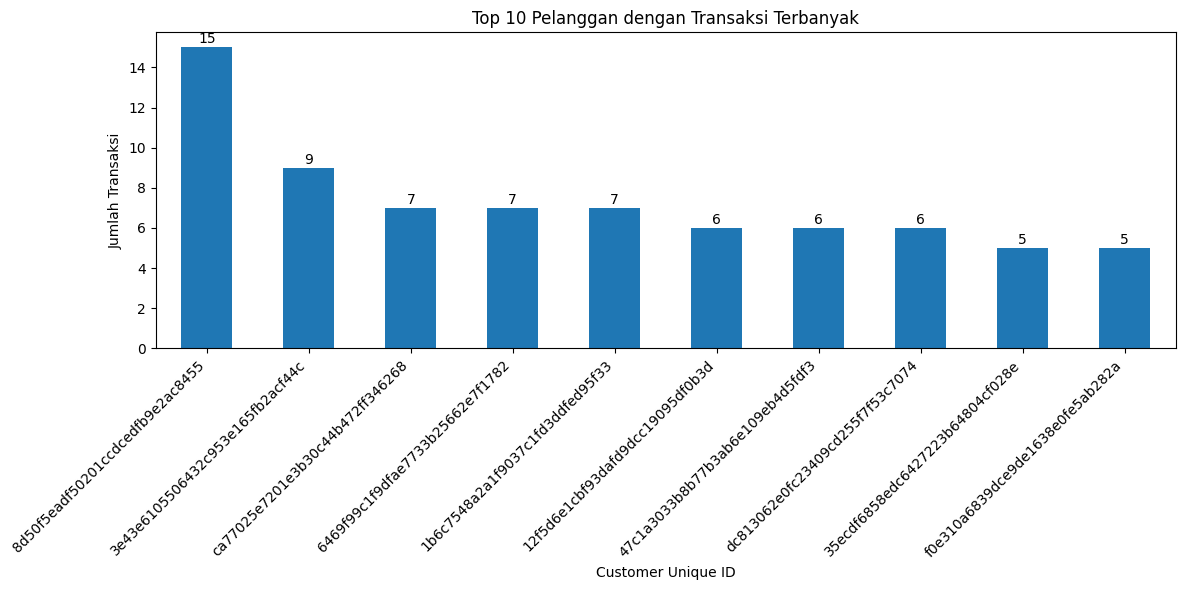

In [50]:
plt.figure(figsize=(12,6))

bars = top_customers.plot(kind='bar')

plt.title('Top 10 Pelanggan dengan Transaksi Terbanyak')
plt.xlabel('Customer Unique ID')
plt.ylabel('Jumlah Transaksi')

plt.xticks(rotation=45, ha='right')

for i, v in enumerate(top_customers.values):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan visualisasi, terdapat beberapa pelanggan yang memiliki jumlah transaksi lebih tinggi dibandingkan pelanggan lainnya, dengan pelanggan tertinggi mencapai sekitar 15 transaksi.

- Hal ini menunjukkan bahwa terdapat pelanggan yang melakukan pembelian berulang, yang dapat dianggap sebagai pelanggan aktif atau loyal.

- Namun, selisih jumlah transaksi antara pelanggan tertinggi dan pelanggan lainnya tidak terlalu jauh, yang menunjukkan bahwa distribusi aktivitas pelanggan relatif tidak terlalu timpang.

- Secara umum, aktivitas pelanggan bervariasi, namun sebagian besar pelanggan berada pada tingkat transaksi yang tidak terlalu tinggi.

### Pertanyaan 4: Kategori produk apa yang paling banyak terjual berdasarkan jumlah item yang dibeli oleh pelanggan selama periode dataset?

In [51]:
category_sales = all_df.groupby('product_category_name')['order_item_id'].count().sort_values(ascending=False)

top_categories = category_sales.head(10)
top_categories

,order_item_id
product_category_name,
cama_mesa_banho,11115
beleza_saude,9670
esporte_lazer,8641
moveis_decoracao,8334
informatica_acessorios,7827
utilidades_domesticas,6964
relogios_presentes,5991
telefonia,4545
ferramentas_jardim,4347


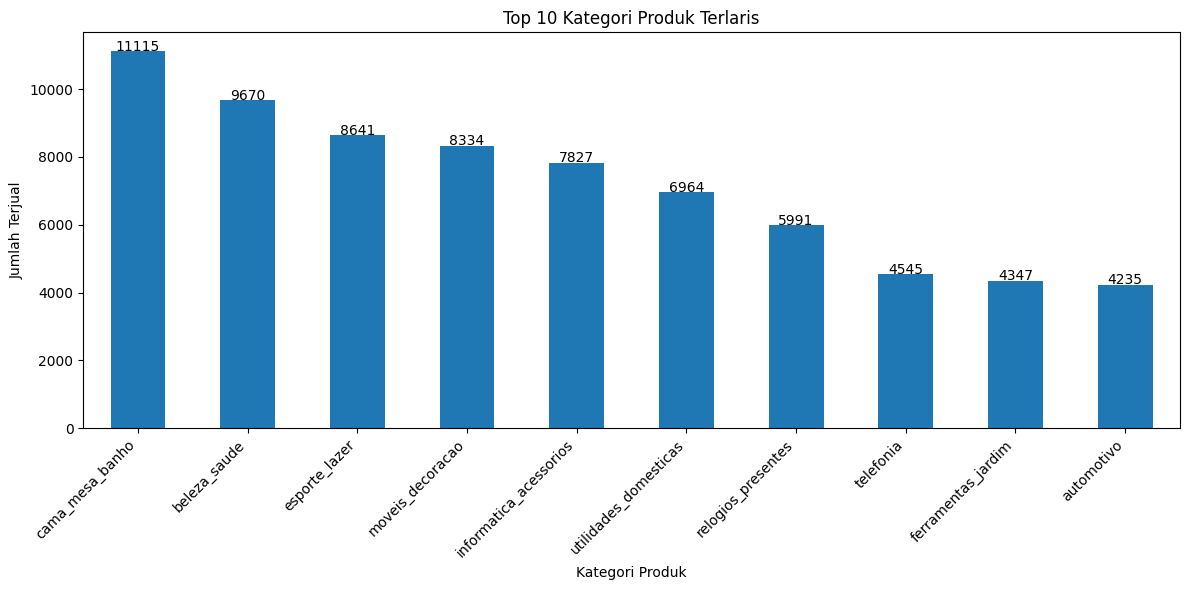

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

bars = top_categories.plot(kind='bar')

plt.title('Top 10 Kategori Produk Terlaris')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Terjual')

plt.xticks(rotation=45, ha='right')

for i, v in enumerate(top_categories.values):
    plt.text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan visualisasi, kategori produk cama_mesa_banho memiliki jumlah penjualan tertinggi dibandingkan kategori lainnya, dengan total penjualan lebih dari 11.000 item.

- Kategori lain seperti beleza_saude dan esporte_lazer juga menunjukkan jumlah penjualan yang tinggi, namun masih berada di bawah kategori utama.

- Hal ini menunjukkan bahwa minat pelanggan lebih besar pada kategori tertentu, khususnya produk kebutuhan rumah tangga dan gaya hidup.

- Perbedaan jumlah penjualan antar kategori cukup terlihat, yang menunjukkan adanya variasi preferensi pelanggan terhadap jenis produk yang ditawarkan.

## Analisis Lanjutan (Opsional)

In [53]:
latest_date = all_df['order_purchase_timestamp'].max()

rfm_df = all_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
})

rfm_df.columns = ['recency', 'frequency', 'monetary']

rfm_df.head()

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90
0000f46a3911fa3c0805444483337064,541,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99
0004aac84e0df4da2b147fca70cf8255,292,1,180.00


In [54]:
rfm_df.describe()

,recency,frequency,monetary
count,94108.000000,94108.000000,94108.00000
mean,241.882964,1.033674,142.51826
std,153.178338,0.208939,217.54602
min,0.000000,1.000000,0.85000
25%,118.000000,1.000000,47.90000
50%,222.000000,1.000000,89.80000
75%,351.000000,1.000000,155.80000
max,728.000000,15.000000,13440.00000


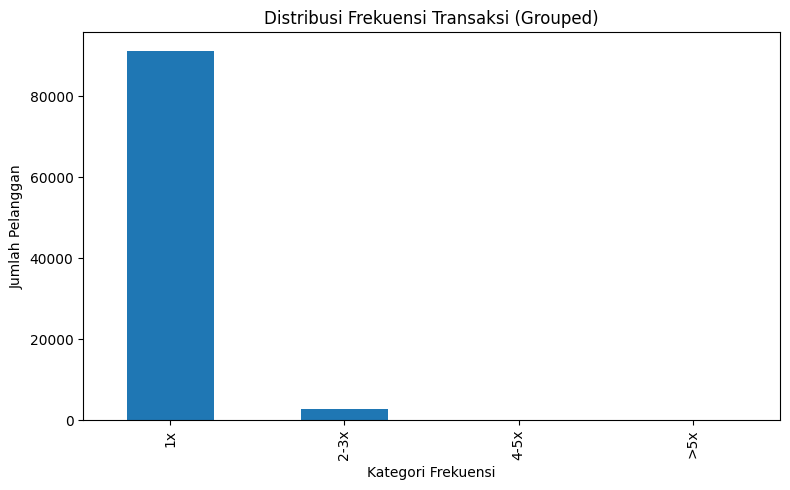

In [55]:
def group_freq(x):
    if x == 1:
        return '1x'
    elif x <= 3:
        return '2-3x'
    elif x <= 5:
        return '4-5x'
    else:
        return '>5x'

rfm_df['freq_group'] = rfm_df['frequency'].apply(group_freq)

freq_group_dist = rfm_df['freq_group'].value_counts()

plt.figure(figsize=(8,5))

freq_group_dist.plot(kind='bar')

plt.title('Distribusi Frekuensi Transaksi (Grouped)')
plt.xlabel('Kategori Frekuensi')
plt.ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

**Insight Frequency:**

- Berdasarkan visualisasi, sebagian besar pelanggan hanya melakukan satu kali transaksi, yang terlihat dari dominasi kategori "1x".

- Jumlah pelanggan yang melakukan transaksi lebih dari satu kali relatif sangat sedikit, yang menunjukkan bahwa tingkat pembelian ulang (repeat purchase) masih rendah.

- Hal ini mengindikasikan bahwa sebagian besar pelanggan belum menjadi pelanggan tetap, melainkan hanya melakukan pembelian satu kali.

- Meskipun demikian, terdapat sebagian kecil pelanggan yang melakukan transaksi lebih dari satu kali, yang dapat menjadi target untuk strategi peningkatan loyalitas pelanggan.

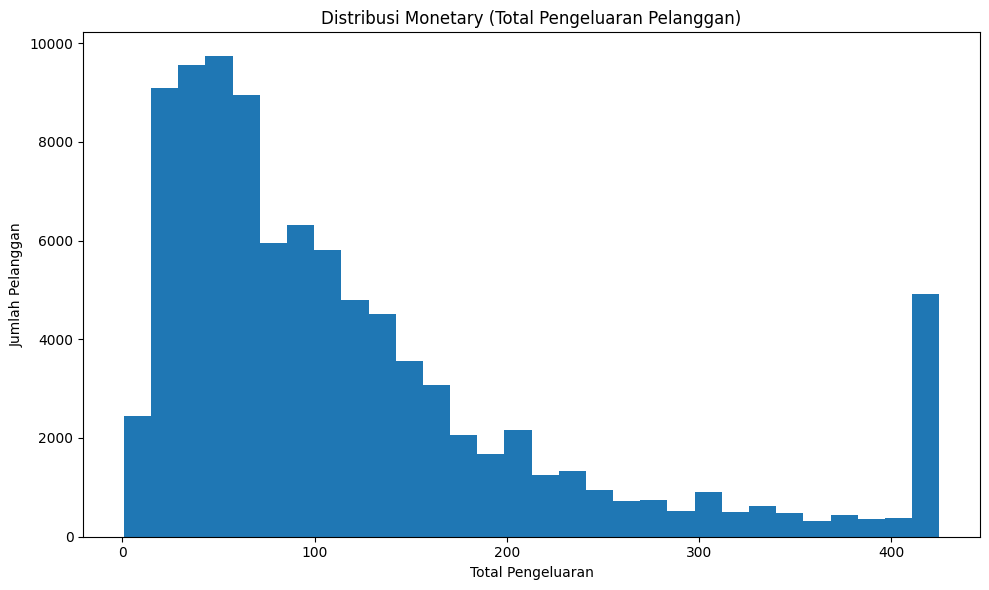

In [56]:
plt.figure(figsize=(10,6))

rfm_df['monetary'].clip(upper=rfm_df['monetary'].quantile(0.95)).plot(kind='hist', bins=30)

plt.title('Distribusi Monetary (Total Pengeluaran Pelanggan)')
plt.xlabel('Total Pengeluaran')
plt.ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

**Insight Monetary:**

- Distribusi monetary menunjukkan pola right-skewed, di mana sebagian besar pelanggan memiliki total pengeluaran yang relatif rendah.

- Terdapat sedikit pelanggan dengan nilai pengeluaran yang jauh lebih tinggi dibandingkan mayoritas, yang membentuk ekor distribusi di sisi kanan.
Hal ini mengindikasikan bahwa kontribusi pendapatan kemungkinan besar didominasi oleh sebagian kecil pelanggan (high-value customers).

- Oleh karena itu, penting untuk mempertahankan pelanggan dengan nilai pengeluaran tinggi serta mendorong pelanggan lain untuk meningkatkan nilai transaksi mereka.

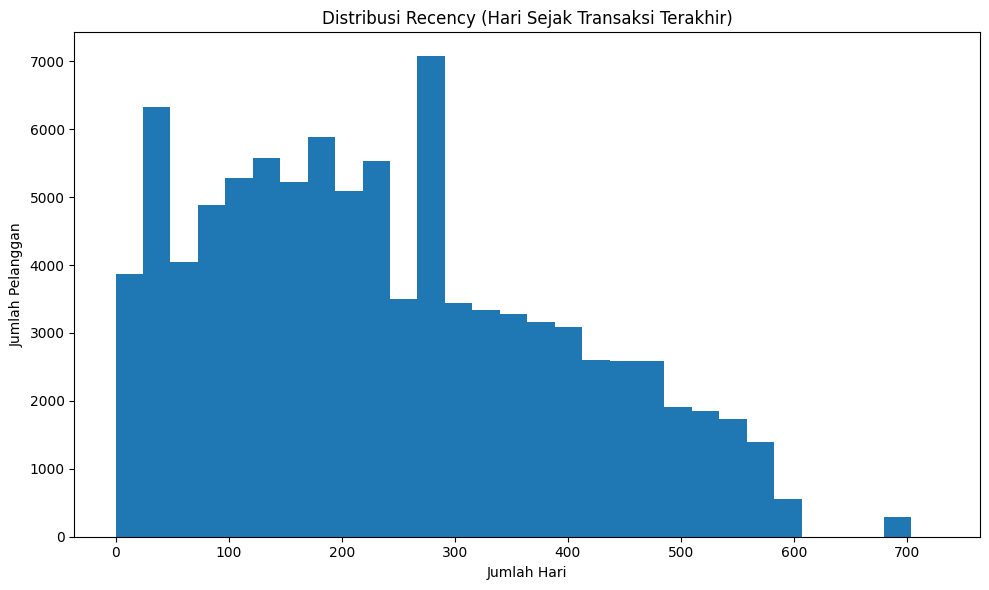

In [57]:
plt.figure(figsize=(10,6))

rfm_df['recency'].plot(kind='hist', bins=30)

plt.title('Distribusi Recency (Hari Sejak Transaksi Terakhir)')
plt.xlabel('Jumlah Hari')
plt.ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

**Insight Recency:**

- Distribusi recency menunjukkan bahwa terdapat variasi waktu yang cukup besar sejak terakhir pelanggan melakukan transaksi.

- Sebagian pelanggan memiliki nilai recency yang rendah, yang menandakan bahwa mereka masih aktif dalam melakukan pembelian.

- Namun, terdapat juga pelanggan dengan nilai recency yang tinggi, yang mengindikasikan bahwa mereka sudah lama tidak melakukan transaksi. Hal ini menunjukkan adanya potensi churn, sehingga diperlukan strategi re-engagement untuk mengaktifkan kembali pelanggan yang sudah lama tidak bertransaksi.

Secara keseluruhan, analisis RFM menunjukkan bahwa mayoritas pelanggan masih berada pada kategori dengan nilai recency tinggi, frequency rendah, dan monetary rendah, sehingga diperlukan strategi untuk meningkatkan retensi dan nilai pelanggan.

## Conclusion

**Conclusion:**

Pertanyaan 1:
Produk dengan penjualan tertinggi berhasil diidentifikasi, di mana produk teratas memiliki jumlah transaksi lebih dari 500. Terlihat adanya penurunan jumlah penjualan pada produk lainnya, yang menunjukkan bahwa tidak semua produk memiliki tingkat permintaan yang sama.

Pertanyaan 2:
Tren jumlah transaksi menunjukkan peningkatan yang signifikan dari awal periode hingga mencapai puncaknya pada akhir tahun 2017. Setelah itu, transaksi cenderung stabil dengan fluktuasi kecil, sedangkan penurunan drastis di akhir periode kemungkinan disebabkan oleh data yang belum lengkap.

Pertanyaan 3:
Terdapat pelanggan yang lebih aktif dalam melakukan transaksi dengan jumlah transaksi tertinggi sekitar 15. Namun, secara keseluruhan aktivitas pelanggan tidak terlalu timpang karena selisih transaksi antar pelanggan relatif tidak jauh.

Pertanyaan 4:
Kategori produk seperti cama_mesa_banho, beleza_saude, dan esporte_lazer memiliki jumlah penjualan tertinggi dibandingkan kategori lainnya, yang menunjukkan bahwa kategori tersebut lebih diminati oleh pelanggan.

Secara keseluruhan, hasil analisis menunjukkan adanya variasi dalam performa produk, tren transaksi yang berkembang dari waktu ke waktu, serta perbedaan tingkat aktivitas pelanggan. Hal ini dapat menjadi dasar dalam pengambilan keputusan bisnis, seperti pengelolaan produk unggulan, strategi pemasaran berbasis tren, dan peningkatan loyalitas pelanggan.

In [59]:
# Melakukan sampling sebesar 60% dari total data
# Tujuan: mengurangi ukuran file agar dapat diupload ke GitHub (<25MB)
# tanpa menghilangkan pola utama dalam data

sample_df = all_df.sample(frac=0.6, random_state=42)
sample_df.to_csv('main_data.csv', index=False)